# BLS / FRED Roofing Material Index Analysis

Exploratory analysis of the **national** monthly price indexes used to time-adjust
(escalate / backcast) retailer-scraped roofing material prices.

**These are national inflation indexes, not local prices.** They are used only for
*time adjustment*. Local geography must come from retailer scraping or other sources.

Prerequisites:

```powershell
python -m src.fetch_fred_indexes
python -m src.build_material_escalation_factors --base-month 2024-01
```

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Make `src` importable when running from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INDEX_PATH = PROJECT_ROOT / "data_intermediate" / "fred_indexes.parquet"
FACTORS_PATH = PROJECT_ROOT / "data_output" / "material_escalation_factors.parquet"

print("Index file:  ", INDEX_PATH, INDEX_PATH.exists())
print("Factors file:", FACTORS_PATH, FACTORS_PATH.exists())

Index file:   c:\Users\ajj4p\Documents\GitHub\Installation_Cost_Research_Database_CADENCE\roofing-cost-model\data_intermediate\fred_indexes.parquet True
Factors file: c:\Users\ajj4p\Documents\GitHub\Installation_Cost_Research_Database_CADENCE\roofing-cost-model\data_output\material_escalation_factors.parquet True


## 1. Load the normalized FRED/BLS index data

In [2]:
indexes = pd.read_parquet(INDEX_PATH)
indexes["date"] = pd.to_datetime(indexes["date"])
indexes["value"] = pd.to_numeric(indexes["value"], errors="coerce")
indexes = indexes.dropna(subset=["date", "value"])
print(f"{len(indexes):,} observations across {indexes['series_id'].nunique()} series")
indexes.head()

2,489 observations across 7 series


,series_id,series_name,date,value,source,material_mapping,use_case,priority,pulled_at
0,WPU1361,"PPI: Prepared Asphalt, Tar Roofing and Siding ...",2000-01-01,96.8,bls,"[asphalt_3_tab, asphalt_architectural, asphalt...",Primary escalation index for asphalt shingle p...,1,2026-06-28T01:45:55.744631+00:00
1,WPU1361,"PPI: Prepared Asphalt, Tar Roofing and Siding ...",2000-02-01,95.6,bls,"[asphalt_3_tab, asphalt_architectural, asphalt...",Primary escalation index for asphalt shingle p...,1,2026-06-28T01:45:55.744631+00:00
2,WPU1361,"PPI: Prepared Asphalt, Tar Roofing and Siding ...",2000-03-01,96.8,bls,"[asphalt_3_tab, asphalt_architectural, asphalt...",Primary escalation index for asphalt shingle p...,1,2026-06-28T01:45:55.744631+00:00
3,WPU1361,"PPI: Prepared Asphalt, Tar Roofing and Siding ...",2000-04-01,99.4,bls,"[asphalt_3_tab, asphalt_architectural, asphalt...",Primary escalation index for asphalt shingle p...,1,2026-06-28T01:45:55.744631+00:00
4,WPU1361,"PPI: Prepared Asphalt, Tar Roofing and Siding ...",2000-05-01,100.8,bls,"[asphalt_3_tab, asphalt_architectural, asphalt...",Primary escalation index for asphalt shingle p...,1,2026-06-28T01:45:55.744631+00:00


## 2. Plot each candidate index over time

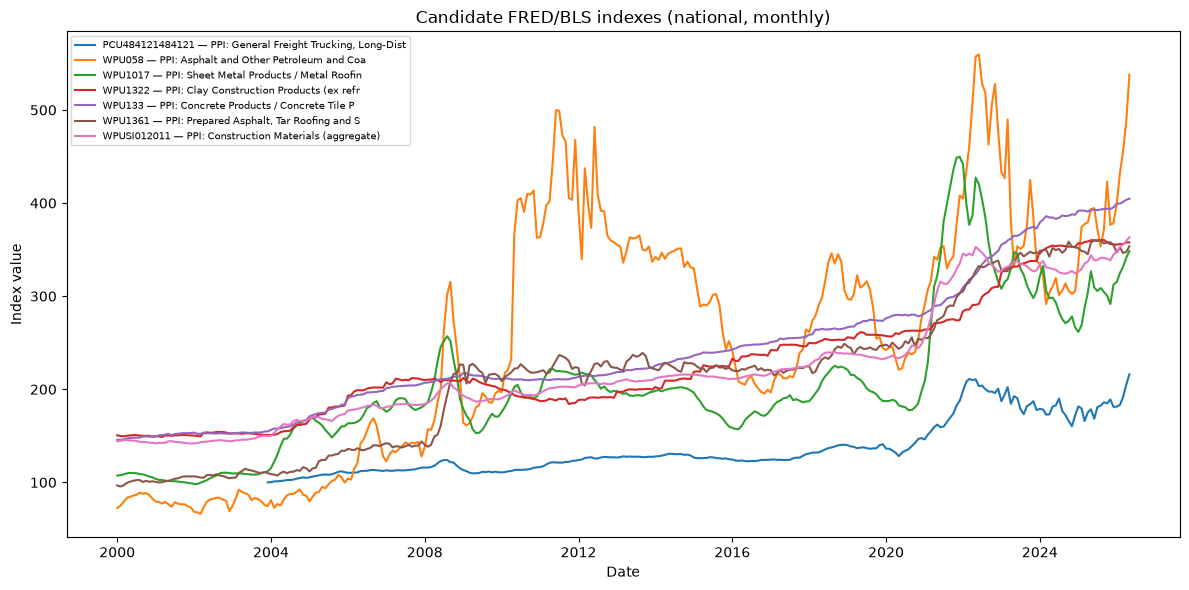

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for series_id, grp in indexes.sort_values("date").groupby("series_id"):
    label = f"{series_id} — {grp['series_name'].iloc[0][:40]}"
    ax.plot(grp["date"], grp["value"], label=label)
ax.set_title("Candidate FRED/BLS indexes (national, monthly)")
ax.set_xlabel("Date")
ax.set_ylabel("Index value")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Escalation factors by material class

Base month: 2024-01


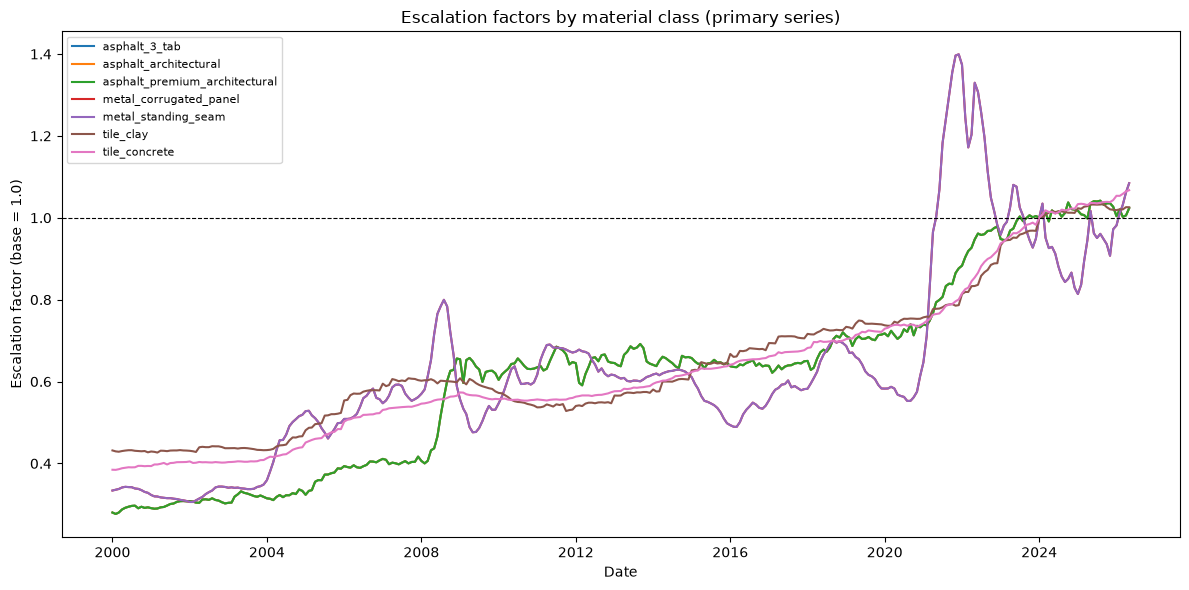

In [4]:
factors = pd.read_parquet(FACTORS_PATH)
factors["date"] = pd.to_datetime(factors["date"])
print(f"Base month: {factors['base_month'].iloc[0]}")

fig, ax = plt.subplots(figsize=(12, 6))
for material_class, grp in factors.sort_values("date").groupby("material_class"):
    # Use the highest-priority (lowest number) series per material class.
    top = grp[grp["priority"] == grp["priority"].min()]
    series_id = top["series_id"].iloc[0]
    sub = top[top["series_id"] == series_id].sort_values("date")
    ax.plot(sub["date"], sub["escalation_factor"], label=material_class)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Escalation factors by material class (primary series)")
ax.set_xlabel("Date")
ax.set_ylabel("Escalation factor (base = 1.0)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Asphalt-related vs metal-related indexes

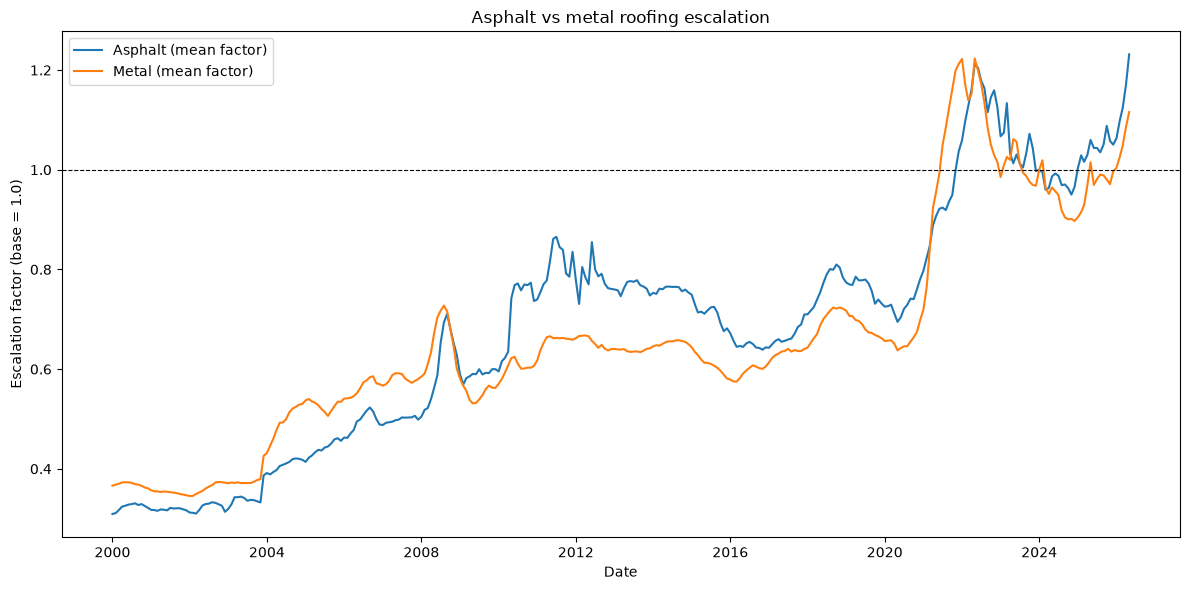

In [5]:
asphalt_classes = factors["material_class"].str.startswith("asphalt")
metal_classes = factors["material_class"].str.startswith("metal")

asphalt = (
    factors[asphalt_classes].groupby("date")["escalation_factor"].mean()
)
metal = factors[metal_classes].groupby("date")["escalation_factor"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(asphalt.index, asphalt.values, label="Asphalt (mean factor)")
ax.plot(metal.index, metal.values, label="Metal (mean factor)")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Asphalt vs metal roofing escalation")
ax.set_xlabel("Date")
ax.set_ylabel("Escalation factor (base = 1.0)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Identify missing months per series

In [6]:
def missing_months(grp: pd.DataFrame) -> list[str]:
    months = grp["date"].dt.to_period("M")
    full = pd.period_range(months.min(), months.max(), freq="M")
    gaps = full.difference(pd.PeriodIndex(months.unique()))
    return [str(g) for g in gaps]


for series_id, grp in indexes.groupby("series_id"):
    gaps = missing_months(grp)
    flag = "OK" if not gaps else f"{len(gaps)} missing"
    print(f"{series_id:16s} {flag}")
    if gaps:
        print("   ", ", ".join(gaps[:12]), "..." if len(gaps) > 12 else "")

PCU484121484121  OK
WPU058           OK
WPU1017          OK
WPU1322          OK
WPU133           OK
WPU1361          OK
WPUSI012011      OK


## 6. Latest available observation date by series

In [7]:
latest = (
    indexes.groupby(["series_id", "series_name"])["date"]
    .max()
    .reset_index()
    .rename(columns={"date": "latest_observation"})
    .sort_values("latest_observation")
)
latest

,series_id,series_name,latest_observation
0,PCU484121484121,"PPI: General Freight Trucking, Long-Distance T...",2026-05-01
1,WPU058,PPI: Asphalt and Other Petroleum and Coal Prod...,2026-05-01
2,WPU1017,PPI: Sheet Metal Products / Metal Roofing Prod...,2026-05-01
3,WPU1017,PPI: Steel Mill Products,2026-05-01
4,WPU1322,PPI: Clay Construction Products (ex refractori...,2026-05-01
5,WPU133,PPI: Concrete Products / Concrete Tile Proxy,2026-05-01
6,WPU1361,"PPI: Prepared Asphalt, Tar Roofing and Siding ...",2026-05-01
7,WPUSI012011,PPI: Construction Materials (aggregate),2026-05-01


## Summary

- **National, not local.** Every series here is a national price *index*. None of
  them carries geography. They describe how material costs have moved *over time*,
  not what a material costs in a given metro.
- **Time adjustment only.** The escalation factors are multipliers used to move an
  observed retailer price from one month to another:
  `adjusted = observed * index(t1) / index(t0)`.
- **Local geography comes from elsewhere.** Local price levels must come from the
  retailer scraping pipeline (Home Depot, Lowe's, etc.) or other local sources.
- **Material mapping is approximate.** Public PPI series rarely match a specific
  roofing product exactly (e.g. clay roof tile is proxied by clay construction
  products). Every `series_id` in `config/bls_fred_series.yml` is a candidate marked
  `verified: false` and should be reviewed against FRED/BLS before production use.